# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [ ]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [ ]:
!mkdir -p data
!wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

--2026-03-20 13:14:23--  https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/cards.png [following]
--2026-03-20 13:14:24--  https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/cards.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77914 (76K) [image/png]
Saving to: ‘data/cards.png’

data/cards.png      100%[===================>]  76.09K  --.-KB/s    in 0.01s   

2026-03-20 13:14:24 (5.02 MB/s) - ‘data/cards.png’ saved [77914/77914]



# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

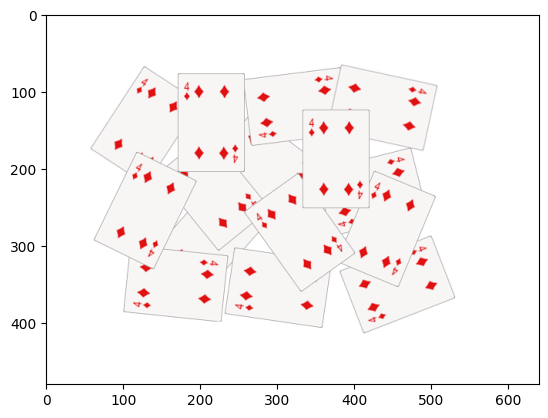

In [ ]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

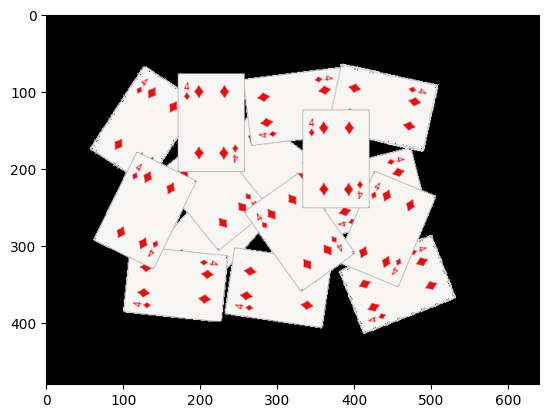

In [ ]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

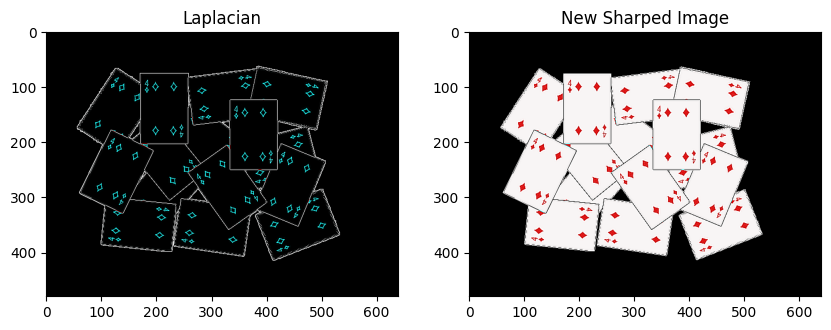

In [ ]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

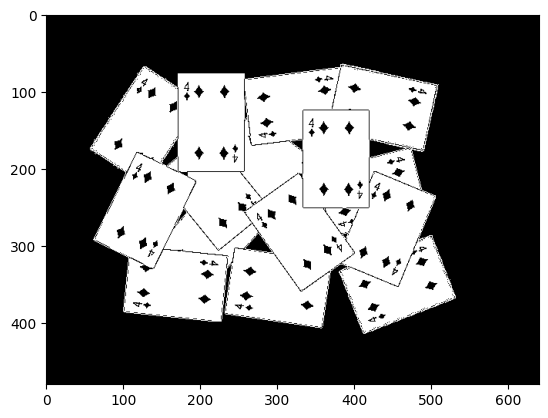

In [ ]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

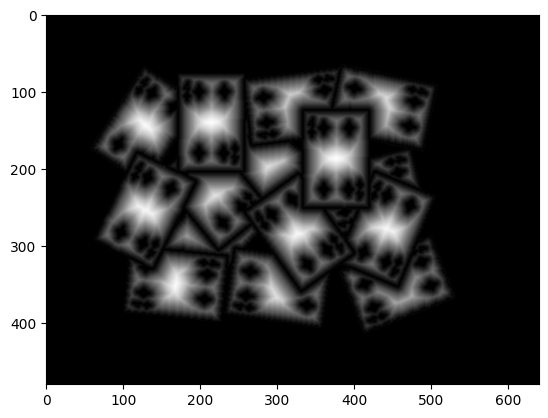

In [ ]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

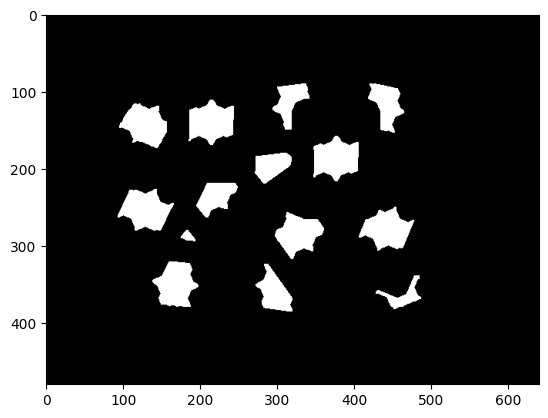

In [ ]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

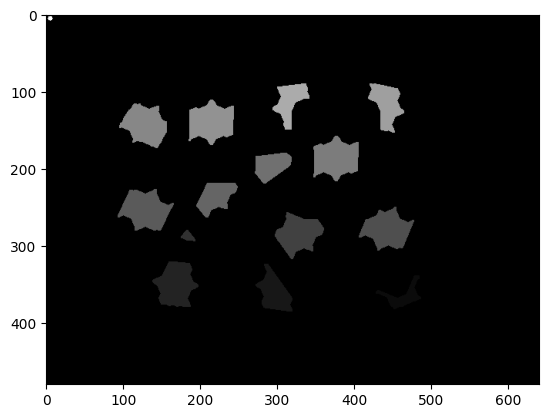

In [ ]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

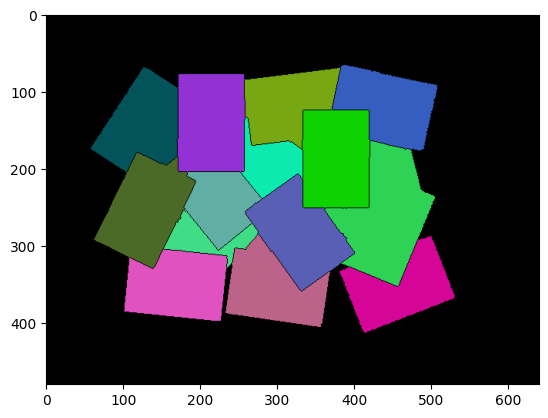

In [ ]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

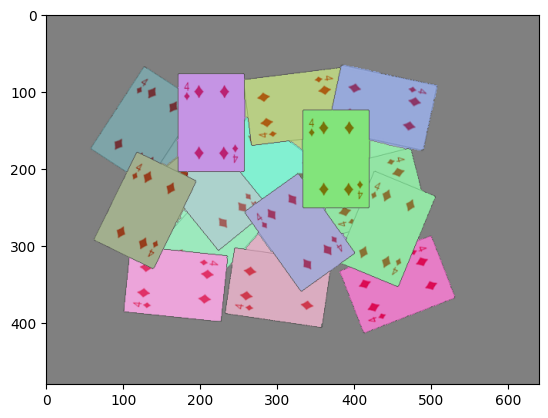

In [ ]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

In [ ]:
# Суть подхода: находим контур руки, строим его выпуклую оболочку,
# затем выделяем дефекты выпуклости (впадины между пальцами).
# Количество таких дефектов плюс один даёт число пальцев.

import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_fingers(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_copy = img_rgb.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0, img_copy

    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull_points = cv2.convexHull(hand_contour, returnPoints=True)

    if len(hull) > 3:
        defects = cv2.convexityDefects(hand_contour, hull)
        if defects is not None:
            filtered_defects = []
            for i in range(defects.shape[0]):
                s, e, f, d = defects[i, 0]
                start = tuple(hand_contour[s][0])
                end = tuple(hand_contour[e][0])
                far = tuple(hand_contour[f][0])

                a = np.sqrt((end[0]-start[0])**2 + (end[1]-start[1])**2)
                b = np.sqrt((far[0]-start[0])**2 + (far[1]-start[1])**2)
                c = np.sqrt((end[0]-far[0])**2 + (end[1]-far[1])**2)
                if b*c > 0:
                    angle = np.arccos((b**2 + c**2 - a**2) / (2*b*c)) * 180 / np.pi
                else:
                    angle = 180
                depth = d / 256
                if depth > 10 and angle < 90:
                    filtered_defects.append((start, end, far, depth, angle))

            # пальцев = дефектов + 1 (если есть дефекты)
            finger_count = len(filtered_defects) + 1 if filtered_defects else 0

            print(f"Найдено пальцев: {finger_count}")

            cv2.drawContours(img_copy, [hand_contour], -1, (0,255,0), 2)
            cv2.drawContours(img_copy, [hull_points], -1, (0,0,255), 2)
            for defect in filtered_defects:
                start, end, far, depth, angle = defect
                cv2.circle(img_copy, far, 5, (255,0,0), -1)
                cv2.line(img_copy, start, far, (255,0,0), 1)
                cv2.line(img_copy, end, far, (255,0,0), 1)
            cv2.putText(img_copy, f'Fingers: {finger_count}', (10,30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
            return finger_count, img_copy

    return 0, img_copy

def visualize_result(image_path):
    finger_count, result_img = count_fingers(image_path)
    if result_img is not None:
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        original = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        plt.imshow(original)
        plt.title('Original')
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(result_img)
        plt.title(f'Result: {finger_count} fingers')
        plt.axis('off')
        plt.show()
        return finger_count
    return None


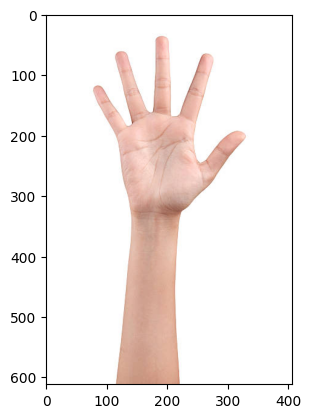

In [ ]:
img = cv2.cvtColor(cv2.imread("data/hand.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

Найдено пальцев: 5


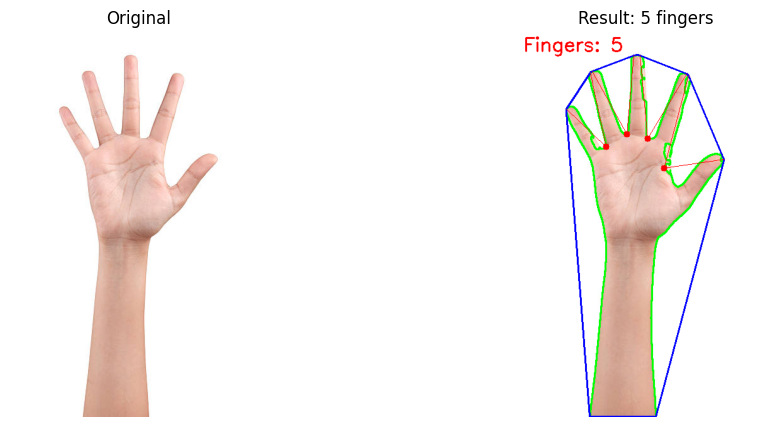

In [ ]:
image_path = "data/hand.jpg"
result = visualize_result(image_path)

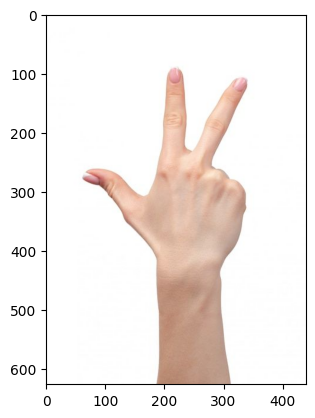

In [ ]:
img = cv2.cvtColor(cv2.imread("data/hand_three.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

Найдено пальцев: 3


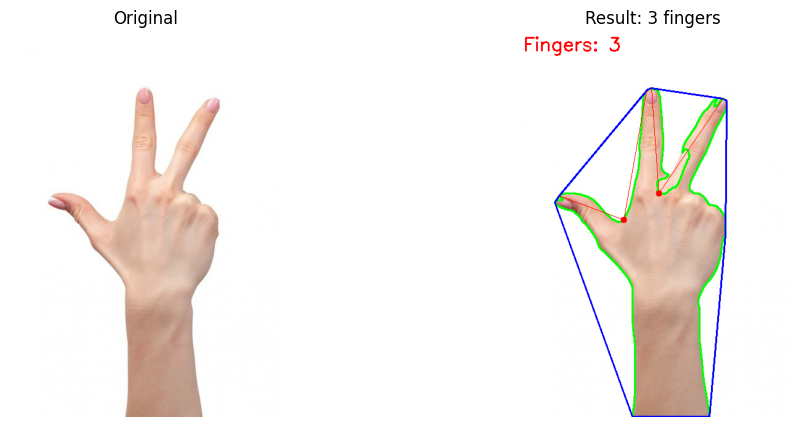

In [ ]:
image_path = "data/hand_three.jpg"
result = visualize_result(image_path)

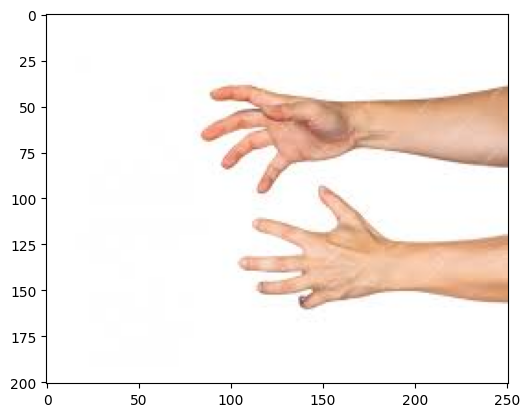

In [ ]:
img = cv2.cvtColor(cv2.imread("data/hand_ten.jpeg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

Найдено пальцев: 4


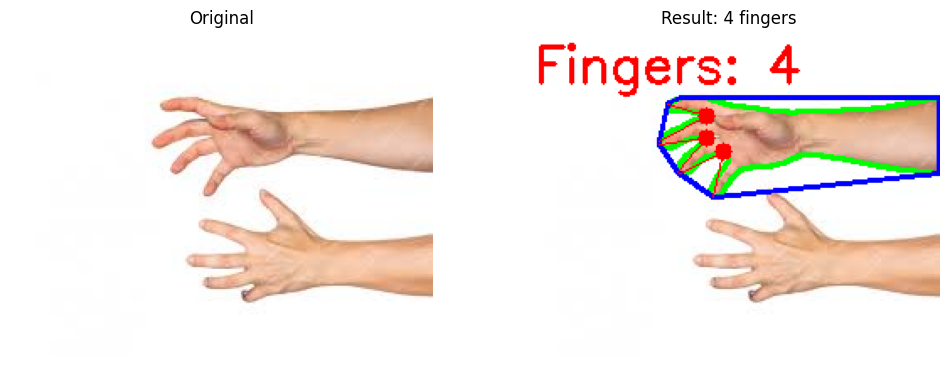

In [ ]:
image_path = "data/hand_ten.jpeg"
result = visualize_result(image_path)

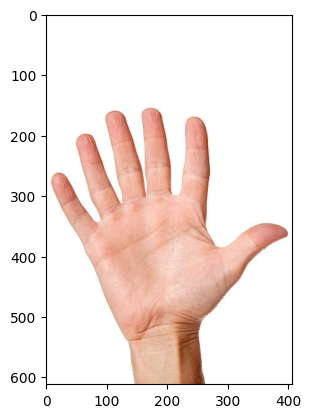

In [ ]:
img = cv2.cvtColor(cv2.imread("data/hand_six.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

Найдено пальцев: 6


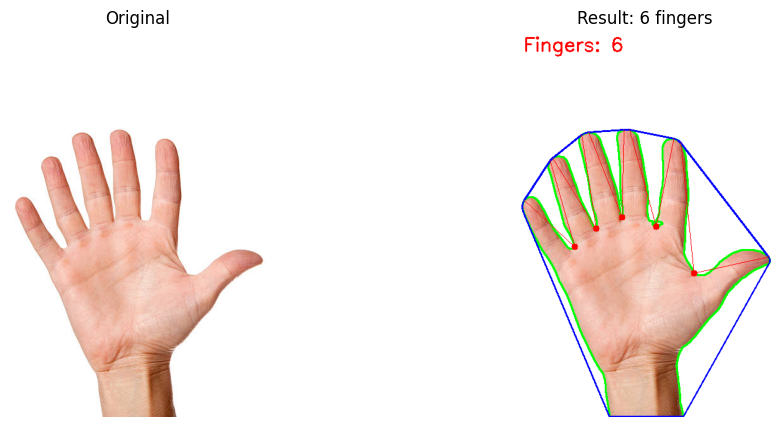

In [ ]:
image_path = "data/hand_six.jpg"
result = visualize_result(image_path)